# Modélisation XGBoost — scénario météo réaliste

Même structure que le notebook "météo parfaite", mais la météo n'est plus celle observée à l'heure visée : on utilise la dernière valeur météo connue à 14h le jour J, persistée pour les 24h de J+1.

## Prochaine étape

Entraînement du modèle XGBoost sur `train`, évaluation sur `val` et `test` (globalement et par `horizon_h`), puis comparaison directe au scénario météo parfaite.

## 7.1 Chargement des splits réalistes déjà sauvegardés

 `entrainer_xgboost.py` reste valable tel quel pour les deux scénarios, seule la source des CSV change.

## 7.3 Entraînement (mêmes réglages anti-surapprentissage que le scénario parfait : learning_rate=0.03, max_depth=5, min_child_weight=3, reg_lambda/reg_alpha, early stopping sur la validation)

Dégradation : +42% d'erreur en passant de la météo observée (scénario parfait, fuite assumée) à la météo réaliste (dernière valeur connue à 14h le jour J, persistée pour les 24h de J+1).

Cette dégradation est plus forte que ce que laissait présager l'importance des features du scénario parfait (où la météo ne pesait que ~5-6% au total de l'importance du modèle). L'explication : l'importance d'une feature dans le modèle "parfait" reflète son utilité quand elle est exacte, pas sa robustesse une fois dégradée en simple persistance. Ici, prédire jusqu'à 34h à l'avance (les horizons tardifs de J+1) en figeant la météo de 14h le jour J ignore les vrais changements de temps qui peuvent survenir dans l'intervalle (front froid nocturne, éclaircie le lendemain) — d'où une perte de précision notable, concentrée sur les périodes où la demande est la plus sensible à la température (chauffage/climatisation).

Point rassurant : le ratio train/val reste proche entre les deux scénarios (1,79 vs 1,66) — la dégradation ne vient donc pas d'un sur-apprentissage supplémentaire, le modèle généralise aussi bien dans les deux cas. C'est le problème lui-même qui devient intrinsèquement plus difficile avec une météo moins fiable, pas un défaut de modélisation.

## 7.4 Évaluation globale et par horizon (sur la validation)

la forme reste globalement similaire au scénario parfait (creux la nuit, remontée en journée) mais avec un changement notable : la bosse du matin (horizon 7-9h) est maintenant presque aussi haute que le pic du soir 985 à 8h contre 1650 MW à 18h

## 7.5 Importance des features

la température gagne beaucoup d'importance par rapport au scénario parfait :

meteo_realiste_temperature_c : 5,1% (nouvelle entrée en haut du classement)
degres_sous_15 : 4,6% (contre 3,2% avant)
meteo_realiste_temperature_c_pondere_pop : 2,2%
→ Total météo ≈ 12% contre ~5-6% dans le scénario parfait.

C'est contre-intuitif à première vue (une feature moins fiable qui devient plus importante), mais logique : le modèle n'a pas d'autre info sur la météo de J+1, donc il s'appuie davantage sur ce proxy imparfait — ce qui amplifie justement l'erreur aux horizons où ce proxy est le plus faux (le matin, comme expliqué ci-dessus).

## 8. Évaluation sur test + comparaison train / val / test (vérification du surapprentissage)

In [15]:
resultats_train, _ = evaluer(modele, X_train, y_train)
resultats_test, pred_test = evaluer(modele, X_test, y_test, horizon_h=test["horizon_h"])

print("--- Scénario réaliste ---")
print(f"Train : MAE {resultats_train['mae']:.1f}")
print(f"Val   : MAE {resultats_val['mae']:.1f}")
print(f"Test  : MAE {resultats_test['mae']:.1f} | RMSE {resultats_test['rmse']:.1f} | MAPE {resultats_test['mape']:.2f}%")


--- Scénario réaliste ---
Train : MAE 807.8
Val   : MAE 1325.1
Test  : MAE 1310.1 | RMSE 1850.4 | MAPE 2.53%


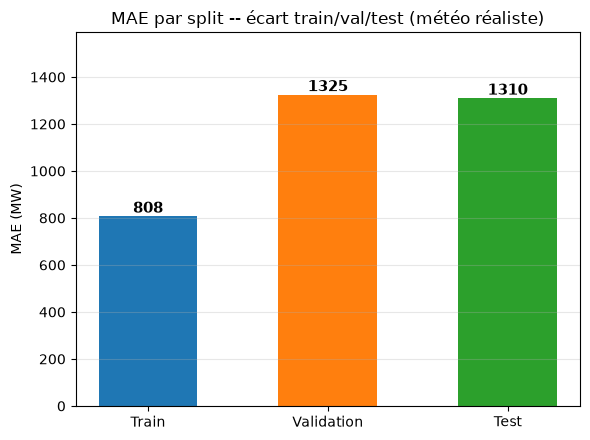

In [16]:
import matplotlib.pyplot as plt

splits = ["Train", "Validation", "Test"]
valeurs = [resultats_train["mae"], resultats_val["mae"], resultats_test["mae"]]
couleurs = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(6, 4.5))
barres = ax.bar(splits, valeurs, color=couleurs, width=0.55)

for barre, hauteur in zip(barres, valeurs):
    ax.text(barre.get_x() + barre.get_width() / 2, hauteur + 15,
            f"{hauteur:.0f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("MAE (MW)")
ax.set_title("MAE par split -- écart train/val/test (météo réaliste)")
ax.set_ylim(0, max(valeurs) * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Réel vs prévu sur un échantillon de test

## 11. Comparaison finale : météo parfaite vs météo réaliste

Les chiffres `MAE_PARFAIT` / `MAPE_PARFAIT` ci-dessous sont ceux obtenus dans le notebook `modelisation_xgboost__meteo_parfaite.ipynb` sur le même jeu de test (2025-2026) : **957.0 MW de MAE, 1304.8 MW de RMSE, 1.88% de MAPE**. Comme les deux notebooks tournent dans des kernels séparés, on les recopie ici en dur pour pouvoir tracer la comparaison -- si tu relances le notebook parfait, pense à mettre ces 3 valeurs à jour.

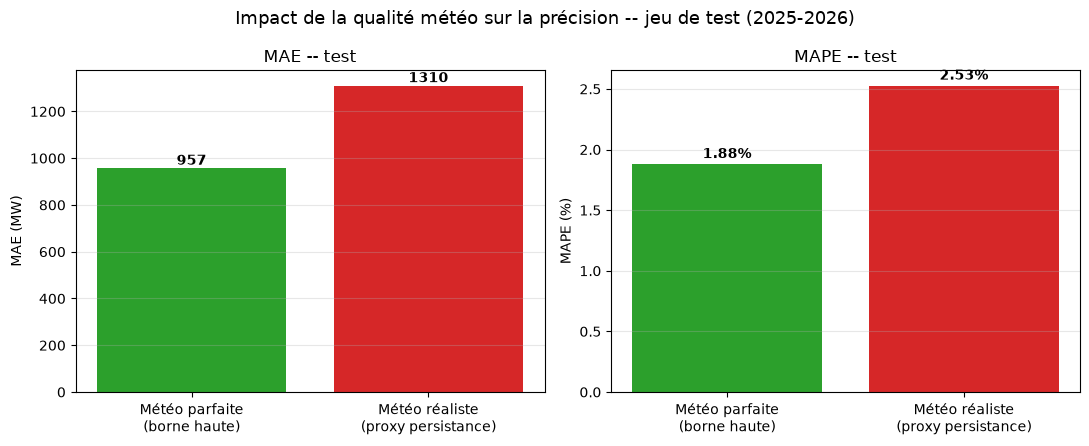

Dégradation MAE parfait -> réaliste : +36.9%


In [19]:
import matplotlib.pyplot as plt

MAE_PARFAIT = 957.0
RMSE_PARFAIT = 1304.8
MAPE_PARFAIT = 1.88

scenarios = ["Météo parfaite\n(borne haute)", "Météo réaliste\n(proxy persistance)"]
mae_valeurs = [MAE_PARFAIT, resultats_test["mae"]]
mape_valeurs = [MAPE_PARFAIT, resultats_test["mape"]]
couleurs = ["#2ca02c", "#d62728"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

barres1 = ax1.bar(scenarios, mae_valeurs, color=couleurs)
for barre, hauteur in zip(barres1, mae_valeurs):
    ax1.text(barre.get_x() + barre.get_width() / 2, hauteur + 15,
              f"{hauteur:.0f}", ha="center", fontweight="bold")
ax1.set_ylabel("MAE (MW)")
ax1.set_title("MAE -- test")
ax1.grid(axis="y", alpha=0.3)

barres2 = ax2.bar(scenarios, mape_valeurs, color=couleurs)
for barre, hauteur in zip(barres2, mape_valeurs):
    ax2.text(barre.get_x() + barre.get_width() / 2, hauteur + 0.05,
              f"{hauteur:.2f}%", ha="center", fontweight="bold")
ax2.set_ylabel("MAPE (%)")
ax2.set_title("MAPE -- test")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Impact de la qualité météo sur la précision -- jeu de test (2025-2026)", fontsize=13)
plt.tight_layout()
plt.show()

degradation = (resultats_test["mae"] - MAE_PARFAIT) / MAE_PARFAIT * 100
print(f"Dégradation MAE parfait -> réaliste : {degradation:+.1f}%")


## Résumé  — météo parfaite vs météo réaliste (jeu de test, 2025-2026)

| Scénario | MAE test | RMSE test | MAPE test | Statut |
|---|---|---|---|---|
| Météo parfaite | 957 MW | 1304.8 MW | 1.88% | Borne haute (irréaliste, fuite assumée) |
| **Météo réaliste** | **1310 MW** | **1850.4 MW** | **2.53%** | **Estimation crédible en production** |
| Baseline J-1 (référence) | 2997 MW | — | 6.07% | — |
| Baseline J-7 (référence) | 3406 MW | — | 6.46% | — |

**Coût de l'absence de vraies prévisions météo historiques** : +37% d'erreur (957 → 1310 MW) entre le scénario parfait et le scénario réaliste.

**Gain de XGBoost (météo réaliste) vs baselines naïves** : -56% à -61% d'erreur par rapport à la persistance J-1/J-7 — le modèle reste largement supérieur à une heuristique simple, même sans accès à de vraies prévisions météo.

## Étude d'ablation

plus le MAE augmente quand on retire un groupe, plus ce groupe est utile.
Si retirer la météo coûte peu, c'est cohérent avec le poids dominant des retards dans l'importance des variables.

In [22]:
import pandas as pd

GROUPES = {
    "météo": [c for c in colonnes_features if c.startswith("meteo_realiste_") or c.startswith("degres_")],
    "calendrier": [c for c in colonnes_features if c in (
        "jour_semaine", "mois", "weekend", "ferie", "vacances", "confinement_numero",
        "jour_annee_sin", "jour_annee_cos", "heure_sin", "heure_cos") or c.startswith("saison_")],
    "retards conso": [c for c in colonnes_features if c.startswith("conso_")],
}

# Vérification : chaque feature appartient à un groupe (sauf horizon_h, toujours gardée)
couvertes = set(sum(GROUPES.values(), []))
print("Non classées :", [c for c in colonnes_features if c not in couvertes])

resultats_ablation = []

# Référence : modèle complet (déjà entraîné)
res_val_ref, _ = evaluer(modele, X_val, y_val)
res_test_ref, _ = evaluer(modele, X_test, y_test)
resultats_ablation.append({"variante": "Modèle complet", "MAE val": res_val_ref["mae"],
                           "MAE test": res_test_ref["mae"], "MAPE test": res_test_ref["mape"]})

for nom_groupe, cols_retirees in GROUPES.items():
    cols_gardees = [c for c in colonnes_features if c not in cols_retirees]
    print(f"\n=== Sans {nom_groupe} ({len(cols_retirees)} variables retirées) ===")
    m = entrainer_xgboost(X_train[cols_gardees], y_train, X_val[cols_gardees], y_val)
    rv, _ = evaluer(m, X_val[cols_gardees], y_val)
    rt, _ = evaluer(m, X_test[cols_gardees], y_test)
    resultats_ablation.append({"variante": f"Sans {nom_groupe}", "MAE val": rv["mae"],
                               "MAE test": rt["mae"], "MAPE test": rt["mape"]})

tableau_ablation = pd.DataFrame(resultats_ablation).set_index("variante")
tableau_ablation["Δ MAE test vs complet"] = tableau_ablation["MAE test"] - tableau_ablation.loc["Modèle complet", "MAE test"]
tableau_ablation["Δ %"] = tableau_ablation["Δ MAE test vs complet"] / tableau_ablation.loc["Modèle complet", "MAE test"] * 100
tableau_ablation.round(1)

Non classées : ['horizon_h']

=== Sans météo (16 variables retirées) ===
[0]	validation_0-mae:9219.97193	validation_1-mae:8166.99266
[50]	validation_0-mae:3196.70408	validation_1-mae:2850.48655
[100]	validation_0-mae:2020.38421	validation_1-mae:1877.08993
[150]	validation_0-mae:1720.40898	validation_1-mae:1675.46976
[200]	validation_0-mae:1600.66461	validation_1-mae:1625.62505
[250]	validation_0-mae:1531.33049	validation_1-mae:1608.15087
[300]	validation_0-mae:1478.52358	validation_1-mae:1592.60381
[350]	validation_0-mae:1433.67447	validation_1-mae:1576.50699
[400]	validation_0-mae:1395.94438	validation_1-mae:1564.96557
[450]	validation_0-mae:1361.82978	validation_1-mae:1556.30119
[500]	validation_0-mae:1332.73547	validation_1-mae:1546.09797
[550]	validation_0-mae:1304.70223	validation_1-mae:1537.54461
[600]	validation_0-mae:1279.88473	validation_1-mae:1530.43364
[650]	validation_0-mae:1258.69891	validation_1-mae:1524.88920
[700]	validation_0-mae:1237.02958	validation_1-mae:1519.60585


,MAE val,MAE test,MAPE test,Δ MAE test vs complet,Δ %
variante,,,,,
Modèle complet,1325.1,1310.1,2.5,0.0,0.0
Sans météo,1482.4,1566.0,3.0,255.9,19.5
Sans calendrier,1994.4,1886.5,3.7,576.4,44.0
Sans retards conso,2603.9,2255.4,4.5,945.3,72.2


- Les retards de consommation sont indispensables : sans eux l'erreur double. C'est cohérent avec leur poids dans l'importance des variables (J-1 et J-7 à eux seuls ~67 %).
- Le calendrier compte beaucoup (+50 %), plus que la météo.
- La météo persistée apporte ~12 %. C'est un apport modeste mais réel, et cohérent avec son poids (~12 %) dans l'importance des variables du modèle réaliste. Avec la météo parfaite, cet apport serait bien plus grand : c'est ce que mesure l'écart de 37 % entre les deux scénarios.
- Sans calendrier ni retards, le modèle sur-apprend plus vite
- L'ablation donne donc l'apport marginal de chaque groupe, pas une décomposition exacte.

##  Analyse des échecs

identifie les jours les plus mal prédits et fournit les éléments pour déterminer la cause de chacun (écart de température entre la persistance et la réalité, jour férié, vacances, biais de la prévision)
**Méthode.** Pour chaque jour de prévision J (origine 14h), on calcule la MAE sur les 24 heures de J+1, le biais (prévu − réel) et l'écart de température entre la moyenne réelle de J+1 et la moyenne des 24 h précédant la coupure. Seuls les jours complets (≥ 23 heures) sont retenus. 

,mae,biais,jour_semaine,ferie,vacances,temp_persistee,n,temp_reelle_J+1,ecart_temp,temp_24h_avant_coupure,ecart_temp_corrige
jour_J,,,,,,,,,,,
2025-01-04,8505.8,8505.8,6,False,3,4.0,24,10.1,6.1,1.6,8.5
2026-01-11,7418.0,7418.0,0,False,0,4.5,24,7.6,3.1,2.6,5.0
2025-01-26,7391.7,7391.7,0,False,0,8.1,24,10.5,2.5,7.1,3.4
2025-01-21,7377.8,7377.8,2,False,0,3.5,24,6.6,3.2,1.7,4.9
2026-01-07,6252.2,6252.2,3,False,0,1.9,24,6.0,4.1,-1.1,7.1
2025-11-17,6031.3,-6031.3,1,False,0,10.8,24,4.4,-6.4,10.4,-6.1
2026-01-12,5826.4,5826.4,1,False,0,10.2,24,10.0,-0.1,5.5,4.5
2026-02-15,4868.9,4868.9,0,False,2,6.0,24,8.9,2.9,3.5,5.4
2026-01-13,4472.9,4472.9,2,False,0,11.9,24,10.2,-1.7,9.6,0.6


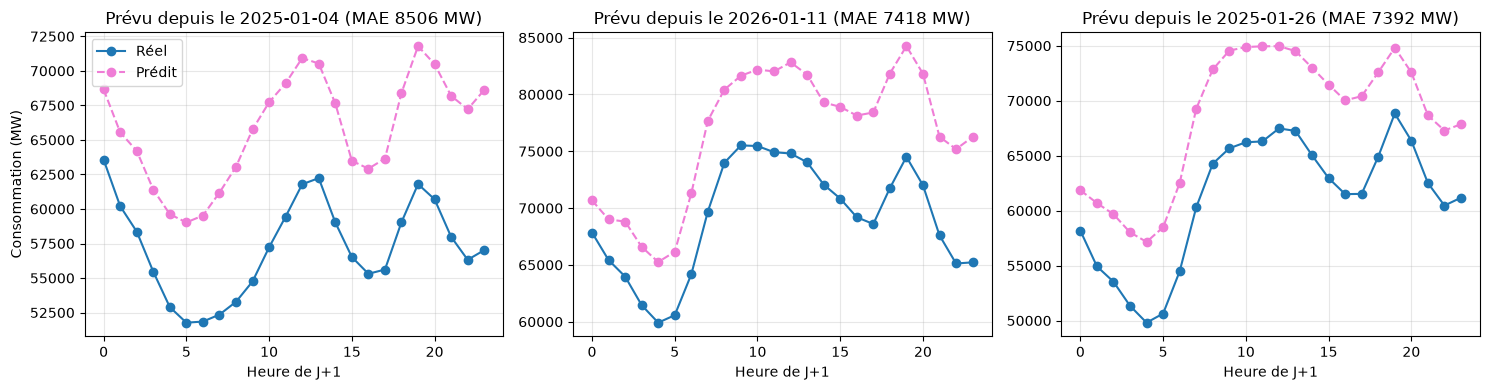

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

diag = test[["date_prevision", "horizon_h", "cible_consommation_mw", "jour_semaine",
             "ferie", "vacances", "meteo_realiste_temperature_c_pondere_pop"]].copy()
diag["pred"] = pred_test
diag["err_abs"] = (diag["cible_consommation_mw"] - diag["pred"]).abs()
diag["err_signee"] = diag["pred"] - diag["cible_consommation_mw"]   # >0 : sur-estimation
diag["jour_J"] = diag["date_prevision"].astype(str).str[:10]

par_jour = diag.groupby("jour_J").agg(
    mae=("err_abs", "mean"),
    biais=("err_signee", "mean"),
    jour_semaine=("jour_semaine", "first"),
    ferie=("ferie", "max"),
    vacances=("vacances", "max"),
    temp_persistee=("meteo_realiste_temperature_c_pondere_pop", "first"),
    n=("err_abs", "size"),
)

# Température réellement observée le jour J+1 (moyenne journalière)
temp_jour = df.groupby(df["timestamp_paris"].dt.strftime("%Y-%m-%d"))["temperature_c_pondere_pop"].mean()
jour_cible = (pd.to_datetime(par_jour.index) + pd.DateOffset(days=1)).strftime("%Y-%m-%d")
par_jour["temp_reelle_J+1"] = temp_jour.reindex(jour_cible).values
par_jour["ecart_temp"] = par_jour["temp_reelle_J+1"] - par_jour["temp_persistee"]

# Température moyenne des 24 h précédant la coupure (jour J, 14h), comparable à une moyenne journalière
temp_idx = df.set_index("timestamp_paris")["temperature_c_pondere_pop"]
temp_24h = temp_idx.rolling("24h").mean()

a_14h = temp_24h[temp_24h.index.hour == 14]
temp_24h_a_14h = pd.Series(a_14h.values, index=a_14h.index.strftime("%Y-%m-%d"))
temp_24h_a_14h = temp_24h_a_14h[~temp_24h_a_14h.index.duplicated()]

par_jour["temp_24h_avant_coupure"] = temp_24h_a_14h.reindex(par_jour.index).values
par_jour["ecart_temp_corrige"] = par_jour["temp_reelle_J+1"] - par_jour["temp_24h_avant_coupure"]

pires = par_jour[par_jour["n"] >= 23].sort_values("mae", ascending=False).head(10)
display(pires.round(1))

# Graphique : réel vs prédit pour les 3 pires jours
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, jour in zip(axes, pires.index[:3]):
    d = diag[diag["jour_J"] == jour].sort_values("horizon_h")
    ax.plot(d["horizon_h"], d["cible_consommation_mw"], marker="o", label="Réel")
    ax.plot(d["horizon_h"], d["pred"], marker="o", linestyle="--", color="#ef7dd6", label="Prédit")
    ax.set_title(f"Prévu depuis le {jour} (MAE {pires.loc[jour, 'mae']:.0f} MW)")
    ax.set_xlabel("Heure de J+1")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend()
plt.tight_layout()
plt.show()


1. **L'erreur est un décalage de niveau, pas de forme.** Pour chaque jour, le biais est égal à la MAE : l'erreur a le même signe sur les 24 heures. Les graphiques montrent que le profil journalier (creux nocturne, pointes du matin et du soir) est bien reproduit, mais toute la courbe est décalée.
2. **Les 10 pires jours sont en saison de chauffage** (novembre à février), quand la consommation est la plus sensible à la température.
3. **Le signe de l'erreur suit la surprise météo dans les 10 cas.** Quand la température réelle de J+1 est plus élevée que celle connue à 14h, le modèle sur-estime (il anticipe un jour plus froid, donc plus de chauffage). Le 2025-11-17, il a fait 6 °C plus froid que prévu et c'est le seul jour sous-estimé.
4. **L'ordre de grandeur est cohérent avec l'EDA.** 
5. **Le calcul de l'écart de température compte.** Comparer la moyenne de J+1 à la seule température de 14h (le moment le plus chaud) sous-estime l'écart de plusieurs degrés en hiver. Avec la moyenne des 24 h précédant la coupure, les jours 2026-01-12 et 2025-01-24 passent d'un écart quasi nul à +4,5 °C et +3,0 °C.

### Conclusion

- Les échecs les plus lourds ont une cause dominante : **le scénario opérationnel ne dispose que d'une persistance de la météo observée à 14h**, sans vraie prévision pour J+1. Une variation de 3 à 8 °C en 24 h en hiver se traduit directement par une erreur de 4 à 8 GW.
- Le modèle est **déconseillé, ou à utiliser avec une marge d'erreur élargie, lors des changements météo rapides en saison de chauffage** (redoux ou coup de froid annoncés pour le lendemain).


# essai d'améliorer la performance de modele sur ces 10 j

In [32]:
from models.xgboost.features_xgboost_v2 import (
    charger_dataset_final, construire_table_horizons, split_train_val_test,
    verifier_table, predire_jour_suivant, PROCESSED_DIR,
)
from models.xgboost.entrainer_xgboost import *

In [33]:
table_v2 = construire_table_horizons(df, scenario="realiste")
print(verifier_table(table_v2), table_v2.shape)
train_v2, val_v2, test_v2 = split_train_val_test(table_v2)

DOSSIER_V2 = PROCESSED_DIR / "xgboost_realiste_v2"
DOSSIER_V2.mkdir(parents=True, exist_ok=True)
train_v2.to_csv(DOSSIER_V2 / "train.csv", index=False)
val_v2.to_csv(DOSSIER_V2 / "val.csv", index=False)
test_v2.to_csv(DOSSIER_V2 / "test.csv", index=False)

{'n_lignes': 93697, 'n_jours_prevision': 3905, 'repartition_nb_horizons_par_jour': {24: 3883, 23: 11, 25: 10, 2: 1}, 'jours_hors_23_24_25': {Timestamp('2026-09-30 00:00:00+0200', tz='Europe/Paris'): 2}, 'cible_manquante': 0} (93697, 48)


In [34]:
tr2, va2, te2 = encoder_categorielles(train_v2, val_v2, test_v2)
X_train2, y_train2, colonnes_v2 = separer_x_y(tr2)
X_val2, y_val2, _ = separer_x_y(va2, colonnes_v2)
X_test2, y_test2, _ = separer_x_y(te2, colonnes_v2)

print(len(colonnes_v2), "features")   # attendu : 47
modele_v2 = entrainer_xgboost(X_train2, y_train2, X_val2, y_val2)

47 features
[0]	validation_0-mae:9219.03937	validation_1-mae:8166.41542
[50]	validation_0-mae:3085.66737	validation_1-mae:2753.36220
[100]	validation_0-mae:1842.04440	validation_1-mae:1737.23345
[150]	validation_0-mae:1504.66907	validation_1-mae:1524.26652
[200]	validation_0-mae:1363.50172	validation_1-mae:1463.47228
[250]	validation_0-mae:1280.19495	validation_1-mae:1430.20972
[300]	validation_0-mae:1218.51531	validation_1-mae:1406.02814
[350]	validation_0-mae:1172.41793	validation_1-mae:1387.95006
[400]	validation_0-mae:1134.91391	validation_1-mae:1372.61406
[450]	validation_0-mae:1100.27460	validation_1-mae:1358.22997
[500]	validation_0-mae:1068.46633	validation_1-mae:1343.74093
[550]	validation_0-mae:1042.67067	validation_1-mae:1335.11627
[600]	validation_0-mae:1018.96600	validation_1-mae:1327.84528
[650]	validation_0-mae:996.27534	validation_1-mae:1319.97534
[700]	validation_0-mae:975.19603	validation_1-mae:1313.93136
[750]	validation_0-mae:957.39396	validation_1-mae:1307.17447
[8

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = modele_v2.predict(X_test2)
mae = mean_absolute_error(y_test2, pred)
rmse = np.sqrt(mean_squared_error(y_test2, pred))
mape = np.mean(np.abs((y_test2 - pred) / y_test2)) * 100
print(f"v2 test : MAE {mae:.1f} | RMSE {rmse:.1f} | MAPE {mape:.2f} % | v1 : 1310.1")

v2 test : MAE 1237.4 | RMSE 1742.3 | MAPE 2.39 % | v1 : 1310.1


In [36]:
V1_MAE = {"2025-01-04": 8505.8, "2026-01-11": 7418.0, "2025-01-26": 7391.7,
          "2025-01-21": 7377.8, "2026-01-07": 6252.2, "2025-11-17": 6031.3,
          "2026-01-12": 5826.4, "2026-02-15": 4868.9, "2026-01-13": 4472.9,
          "2025-01-24": 4210.4}

diag = pd.DataFrame({
    "jour_J": pd.to_datetime(te2["date_prevision"]).dt.strftime("%Y-%m-%d").values,
    "err": np.abs(y_test2.values - pred),
    "biais": y_test2.values - pred,
})
par_jour = diag.groupby("jour_J").agg(mae_v2=("err", "mean"), biais_v2=("biais", "mean"))

comp = par_jour.loc[list(V1_MAE)].copy()
comp.insert(0, "mae_v1", pd.Series(V1_MAE))
comp["reduction_%"] = (100 * (1 - comp["mae_v2"] / comp["mae_v1"])).round(1)
display(comp.round(1))
print("MAE moyenne sur ces 10 jours : v1", round(comp["mae_v1"].mean()), "-> v2", round(comp["mae_v2"].mean()))

,mae_v1,mae_v2,biais_v2,reduction_%
jour_J,,,,
2025-01-04,8505.8,7077.5,-7077.5,16.8
2026-01-11,7418.0,7250.8,-7250.8,2.3
2025-01-26,7391.7,6763.3,-6763.3,8.5
2025-01-21,7377.8,6792.9,-6792.9,7.9
2026-01-07,6252.2,3396.4,-3396.4,45.7
2025-11-17,6031.3,4408.1,4408.1,26.9
2026-01-12,5826.4,3786.1,-3786.1,35.0
2026-02-15,4868.9,3281.0,-3281.0,32.6
2026-01-13,4472.9,3950.4,-3950.4,11.7


MAE moyenne sur ces 10 jours : v1 6236 -> v2 4981


Analyse des échecs (v2).

 Les features météo dérivées (tendances, moyennes 24/48/72h, écart à la normale, froid cumulé) réduisent la MAE test globale de 5,5 % (1 310 → 1 237 MW) mais surtout celle des dix pires jours de la v1, de 20 % en moyenne (6 236 → 4 981 MW ; jusqu'à −46 % le 07/01/2026).

  Quatre jours restent autour de 7 000 MW (04/01/2025, 21 et 26/01/2025, 11/01/2026). Pour ces jours, la température de J+1 diffère de 3 à 6 °C de la dernière observation connue à 14h, et l'erreur est de même signe sur les 24 heures : elle provient d'un changement de temps non anticipable à partir de l'historique seul.
  
   Cette limite est inhérente à l'absence de prévisions météo historiques ; seule une prévision de température de J+1, disponible à 14h, permettrait de la réduire.

In [37]:
import json

modele_v2.save_model(str(DOSSIER_V2 / "modele_xgboost_realiste_v2.json"))
with open(DOSSIER_V2 / "colonnes_features_v2.json", "w") as f:
    json.dump(colonnes_v2, f)
print("Modèle et liste des colonnes sauvegardés dans", DOSSIER_V2)

Modèle et liste des colonnes sauvegardés dans C:\Users\bahri\Desktop\temporal data analysis\ConsommationElectrique\data\processed\xgboost_realiste_v2


Ablation v2 

In [39]:
GROUPES = {
    "météo": [c for c in colonnes_v2 if c.startswith("meteo_realiste_") or c.startswith("degres_")],
    "calendrier": [c for c in colonnes_v2 if c in (
        "jour_semaine", "mois", "weekend", "ferie", "vacances", "confinement_numero",
        "jour_annee_sin", "jour_annee_cos", "heure_sin", "heure_cos")
        or c.startswith("saison_")],
    "retards conso": [c for c in colonnes_v2 if c.startswith("conso_")],
}
classees = {c for cols in GROUPES.values() for c in cols}
print("Non classées :", [c for c in colonnes_v2 if c not in classees])   # attendu : ['horizon_h']

lignes = [{
    "configuration": "Modèle complet (47 features)",
    "n_features": len(colonnes_v2),
    "MAE val": 1227.35,
    "MAE test": round(float(np.mean(np.abs(y_test2 - modele_v2.predict(X_test2)))), 1),
}]

for nom, cols in GROUPES.items():
    garder = [c for c in colonnes_v2 if c not in cols]
    m = entrainer_xgboost(X_train2[garder], y_train2, X_val2[garder], y_val2)
    lignes.append({
        "configuration": f"Sans {nom}",
        "n_features": len(garder),
        "MAE val": round(m.best_score, 1),
        "MAE test": round(float(np.mean(np.abs(y_test2 - m.predict(X_test2[garder])))), 1),
    })

tableau_ablation_v2 = pd.DataFrame(lignes)
tableau_ablation_v2["Δ MAE test vs complet"] = (
    tableau_ablation_v2["MAE test"] - tableau_ablation_v2["MAE test"].iloc[0]).round(1)
display(tableau_ablation_v2)

Non classées : ['horizon_h']
[0]	validation_0-mae:9219.97193	validation_1-mae:8166.99266
[50]	validation_0-mae:3196.70408	validation_1-mae:2850.48655
[100]	validation_0-mae:2020.38421	validation_1-mae:1877.08993
[150]	validation_0-mae:1720.40898	validation_1-mae:1675.46976
[200]	validation_0-mae:1600.66461	validation_1-mae:1625.62505
[250]	validation_0-mae:1531.33049	validation_1-mae:1608.15087
[300]	validation_0-mae:1478.52358	validation_1-mae:1592.60381
[350]	validation_0-mae:1433.67447	validation_1-mae:1576.50699
[400]	validation_0-mae:1395.94438	validation_1-mae:1564.96557
[450]	validation_0-mae:1361.82978	validation_1-mae:1556.30119
[500]	validation_0-mae:1332.73547	validation_1-mae:1546.09797
[550]	validation_0-mae:1304.70223	validation_1-mae:1537.54461
[600]	validation_0-mae:1279.88473	validation_1-mae:1530.43364
[650]	validation_0-mae:1258.69891	validation_1-mae:1524.88920
[700]	validation_0-mae:1237.02958	validation_1-mae:1519.60585
[750]	validation_0-mae:1217.75409	validation

,configuration,n_features,MAE val,MAE test,Δ MAE test vs complet
0,Modèle complet (47 features),47,1227.35,1237.4,0.0
1,Sans météo,22,1482.40,1566.0,328.6
2,Sans calendrier,33,1975.70,1892.2,654.8
3,Sans retards conso,40,2497.70,2131.6,894.2


Pour mesurer l'apport de chaque famille de variables, nous réentraînons le modèle en retirant un groupe à la fois (horizon_h est toujours conservé), avec les mêmes hyperparamètres et l'early stopping sur la validation. 

Le classement est identique en validation et en test. Les retards de consommation (consommation J-1, J-7, J-365/366 et statistiques des dernières 24h) sont les plus importants : sans eux, la MAE test passe de 1 237 à 2 132 MW (+72 %). Ils donnent au modèle le niveau de charge du moment. Le calendrier (jour de la semaine, week-end, jours fériés, vacances, mois, saisonnalité) vient ensuite : +655 MW (+53 %), ce qui reflète la forte structure hebdomadaire et saisonnière de la demande. 

La météo contribue le moins en valeur absolue (+329 MW, +27 %) mais reste utile, bien qu'elle ne soit connue que sous forme d'observation persistée à 14h. Ce gain modeste est cohérent avec notre analyse des échecs : les erreurs les plus fortes proviennent des changements de temps entre J et J+1, qu'une prévision seule pourrait anticiper. 

Limite : les groupes sont corrélés (par exemple les retards de consommation encodent en partie le calendrier), donc ces écarts mesurent l'apport marginal de chaque groupe et ne s'additionnent pas.